In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader


from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, MinMaxScaler, RobustScaler, StandardScaler, FunctionTransformer
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# import umap
import warnings
warnings.filterwarnings('ignore')

In [2]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cpu')

In [3]:
df=pd.read_csv("final_database.csv")

In [4]:
binary_columns = ['jobma_catcher_status',
                  'jobma_catcher_type',
                  'is_premium',
                  'subscription_type_x',
                  'referral_credit',
                  'ai_live_interview',
                  'subscription_type_y',
                  'plan_type',
                  'is_unlimited',
                  'currency'
                 ]

categorical_columns = ['subscription_status',
                       'per_sub_user',
                       'company_size',
                      ]
                   
ordinal_columns = ['sub_user',#
                   'days_since_creation',#
                   'number_of_logins',#
                   'days_since_login',#
                   'wallet_sum',#
                   'subscription_sum',#
                   'subscription_count',#
                   'ai_kit_counts',#
                   'pre_recorded_kit_counts',#
                   'number_of_jobs_posted',#
                   'number_of_pitcher_invitations',#
                   'number_of_pitchers_applied',#
                   'pre_rec_interviews_counts',#
                   'live_interviews_counts',#
                   'ai_interviews_counts',#done
                   ]

In [5]:
# Clean binary values , # Remove negatives and  clamp to 0
def clean_binary(X):
    return X.apply(lambda col: col.map(lambda val: 1 if pd.to_numeric(val, errors='coerce') > 0 else 0))
    
def clean_categorical(X):
    return X.apply(lambda col: col.map(lambda val: str(val).strip().lower() if pd.notnull(val) else 'others'))

def clean_ordinal(X):
    return X.clip(lower=0)

In [6]:
#pipeline 
binary_pipeline = Pipeline(steps=[('cleaner', FunctionTransformer(clean_binary, validate=False)),
                                  ('imputer', SimpleImputer(strategy='most_frequent')),
                                  
                                 ])

categorical_pipeline = Pipeline(steps=[('cleaner', FunctionTransformer(clean_categorical, validate=False)),
                                       ('imputer', SimpleImputer(strategy='most_frequent')),
                                       ('encoder', OneHotEncoder(handle_unknown='ignore', sparse_output=False)),
                                       ('scaler', StandardScaler())

                                      ])

ordinal_pipeline = Pipeline(steps=[('cleaner', FunctionTransformer(clean_ordinal, validate=False)),
                                   ('imputer', SimpleImputer(strategy='median')),
                                   ('scaler', StandardScaler())
                                  ])

# Combined preprocessor
preprocessor = ColumnTransformer(transformers=[('bin', binary_pipeline, binary_columns),
                                               ('cat', categorical_pipeline, categorical_columns),
                                               ('ord', ordinal_pipeline, ordinal_columns)
                                              ])

pipeline = Pipeline([('preprocessing', preprocessor)])

In [7]:
preprocessor

ColumnTransformer(transformers=[('bin',
                                 Pipeline(steps=[('cleaner',
                                                  FunctionTransformer(func=<function clean_binary at 0x000001E8FF3C0280>)),
                                                 ('imputer',
                                                  SimpleImputer(strategy='most_frequent'))]),
                                 ['jobma_catcher_status', 'jobma_catcher_type',
                                  'is_premium', 'subscription_type_x',
                                  'referral_credit', 'ai_live_interview',
                                  'subscription_type_y', 'plan_type',
                                  'is_unli...
                                                 ('scaler', RobustScaler())]),
                                 ['sub_user', 'days_since_creation',
                                  'number_of_logins', 'days_since_login',
                                  'wallet_sum', 'subscription_sum',
                                  'subscription_count', 'ai_kit_counts',
                                  'pre_recorded_kit_counts',
                                  'number_of_jobs_posted',
                                  'number_of_pitcher_invitations',
                                  'number_of_pitchers_applied',
                                  'pre_rec_interviews_counts',
                                  'live_interviews_counts',
                                  'ai_interviews_counts'])])

In [8]:
X = df

In [9]:
X_scaled = pipeline.fit_transform(X)

In [10]:
class CustomDataset(Dataset):
    def __init__(self, data):
        self.data = torch.tensor(data, dtype=torch.float32)

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]

In [11]:
batch_size = 16
X_tensor = torch.tensor(X_scaled, dtype=torch.float32)
dataset = CustomDataset(X_tensor)
dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

In [12]:
len(X_scaled), len(X_tensor), len(dataset), len(dataloader), batch_size

(5546, 5546, 5546, 347, 16)

In [13]:
# Autoencoder for robustness
class AutoEncoder(nn.Module):
    def __init__(self, input_shape):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_shape, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 32)
        )

        self.decoder = nn.Sequential(
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, input_shape)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return encoded, decoded

In [14]:
X_scaled.shape[1], X_tensor.shape[1]

(42, 42)

In [15]:
input_dim = X_tensor.shape[1]
model = AutoEncoder(input_dim)
model.to(device)

AutoEncoder(
  (encoder): Sequential(
    (0): Linear(in_features=42, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=64, bias=True)
    (3): ReLU()
    (4): Linear(in_features=64, out_features=32, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=32, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=42, bias=True)
  )
)

In [16]:
input_dim

42

In [17]:
# Loss functions
mse_loss_function = nn.SmoothL1Loss()
cosine_loss_function = nn.CosineEmbeddingLoss()
# optimizer = optim.Adam(model.parameters(), lr=0.001)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5)

In [18]:
torch.manual_seed(42)

# Training loop
epochs = 50
model.train()

for epoch in range(epochs):
    epoch_total_loss = 0

    for batch_X in dataloader:
        batch_X = batch_X.to(device)

        # Forward pass
        encoded, decoded = model(batch_X)

        # Reconstruction Loss (MSE)
        mse_loss = mse_loss_function(decoded, batch_X)

        # Similarity Loss (Cosine Embedding Loss using shuffled encoded vectors)
        batch_size = encoded.size(0)
        target_labels = torch.ones(batch_size, device=device)

        # Shuffle the encoded vectors randomly
        permuted_indices = torch.randperm(batch_size, device=device)
        encoded_shuffled = encoded[permuted_indices]

        # Calculate Cosine Embedding Loss
        cosine_loss = cosine_loss_function(encoded, encoded_shuffled, target_labels)

        # Total Loss (Reconstruction loss + Similarity loss)
        total_loss = mse_loss + cosine_loss

        # Backpropagation
        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()

        epoch_total_loss += total_loss.item()

    # Average loss over all batches in the epoch
    training_loss = epoch_total_loss / len(dataloader)
    print(f'Epoch {epoch+1}/{epochs} | Training Loss: {training_loss:.5f}')

    # Step the scheduler after each epoch
    scheduler.step(training_loss)

Epoch 1/50 | Training Loss: 4.26374
Epoch 2/50 | Training Loss: 3.60956
Epoch 3/50 | Training Loss: 4.16501
Epoch 4/50 | Training Loss: 2.98861
Epoch 5/50 | Training Loss: 4.15346
Epoch 6/50 | Training Loss: 2.82827
Epoch 7/50 | Training Loss: 2.47920
Epoch 8/50 | Training Loss: 2.98780
Epoch 9/50 | Training Loss: 2.65992
Epoch 10/50 | Training Loss: 3.59294
Epoch 11/50 | Training Loss: 3.01629
Epoch 12/50 | Training Loss: 2.21264
Epoch 13/50 | Training Loss: 2.30020
Epoch 14/50 | Training Loss: 2.20852
Epoch 15/50 | Training Loss: 2.73163
Epoch 16/50 | Training Loss: 1.92893
Epoch 17/50 | Training Loss: 1.76524
Epoch 18/50 | Training Loss: 2.15396
Epoch 19/50 | Training Loss: 1.80019
Epoch 20/50 | Training Loss: 2.32397
Epoch 21/50 | Training Loss: 2.37347
Epoch 22/50 | Training Loss: 1.59395
Epoch 23/50 | Training Loss: 2.99193
Epoch 24/50 | Training Loss: 2.51682
Epoch 25/50 | Training Loss: 2.05920
Epoch 26/50 | Training Loss: 3.00949
Epoch 27/50 | Training Loss: 1.77681
Epoch 28/5

In [19]:
model.eval()
with torch.no_grad():
    encoder, _ = model(X_tensor)
latent_np = encoder.cpu().numpy()

In [20]:
wcss = []
silhouette_scores = []
k_range = range(2,11)

In [21]:
torch.manual_seed(42)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(latent_np)
    wcss.append(kmeans.inertia_)  # Inertia = WCSS
    silhouette_scores.append(silhouette_score(latent_np, labels))

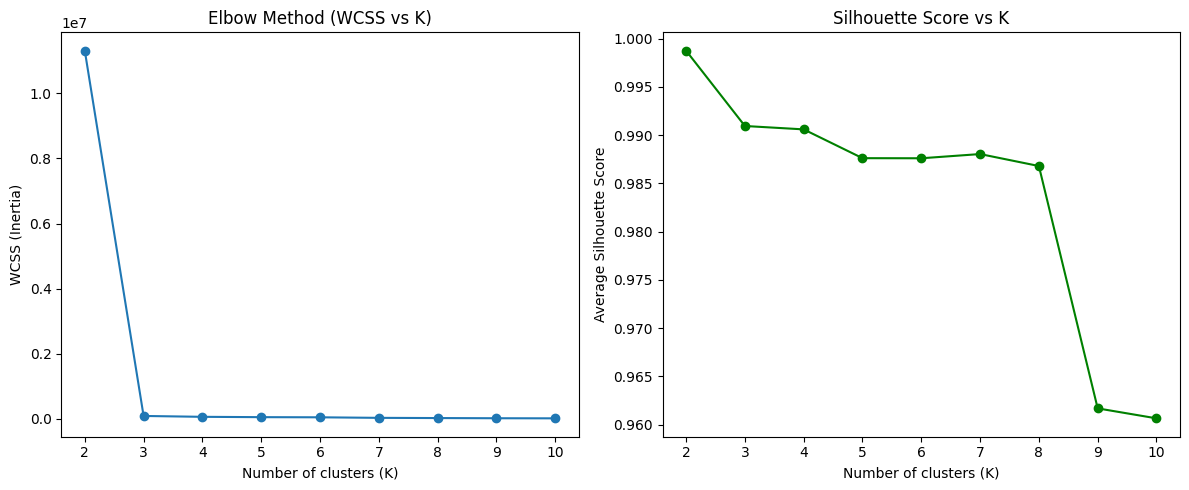

In [22]:
''' Elbow Rule to decide the number of clusters '''
torch.manual_seed(42)
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(k_range, wcss, marker='o')
plt.title('Elbow Method (WCSS vs K)')
plt.xlabel('Number of clusters (K)')
plt.ylabel('WCSS (Inertia)')

# Step 5: Plot Silhouette Scores
plt.subplot(1, 2, 2)
plt.plot(k_range, silhouette_scores, marker='o', color='green')
plt.title('Silhouette Score vs K')
plt.xlabel('Number of clusters (K)')
plt.ylabel('Average Silhouette Score')

plt.tight_layout()
plt.show()

In [23]:
#Initialising KMeans
kmeans = KMeans(n_clusters=3, n_init=50)
cluster_ids = kmeans.fit_predict(latent_np)
cluster_centers = torch.tensor(kmeans.cluster_centers_, dtype=torch.float32).to(device)

In [24]:
# Deep Embedding Clusturing Model
class DEC(nn.Module):
    def __init__(self, encoder, cluster_centers):
        super(DEC, self).__init__()
        self.encoder = encoder
        self.cluster_centers = nn.Parameter(cluster_centers)

    def forward(self, x):
        z = self.encoder(x)
        q = 1.0 / (1.0 + torch.sum((z.unsqueeze(1) - self.cluster_centers)**2, dim=2))
        q = q.pow((1 + 1) / 2.0)
        q = (q.t() / torch.sum(q, dim=1)).t()
        return q, z

def target_distribution(q):
    weight = q**2 / q.sum(0)
    return (weight.t() / weight.sum(1)).t()  

In [25]:
dec = DEC(model.encoder, cluster_centers.clone()).to(device)

In [26]:
kl_loss = nn.KLDivLoss(reduction='batchmean')
optimizer = torch.optim.Adam(dec.parameters(), lr=1e-4)

In [27]:
torch.manual_seed(42)
dec.train()
num_epochs = 20
for epoch in range(num_epochs):
    for batch in dataloader:
        x = batch.to(device)
        q, z = dec(x)
        p = target_distribution(q)

        # Compute loss
        loss = kl_loss(q.log(), p)
        
        # Backpropogation
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    print(f"Epoch {epoch + 1}/{num_epochs}, Loss: {loss.item():.4f}")

Epoch 1/20, Loss: 0.0001
Epoch 2/20, Loss: 0.0001
Epoch 3/20, Loss: 0.0000
Epoch 4/20, Loss: 0.0001
Epoch 5/20, Loss: 0.0001
Epoch 6/20, Loss: 0.0001
Epoch 7/20, Loss: 0.0001
Epoch 8/20, Loss: 0.0001
Epoch 9/20, Loss: 0.0001
Epoch 10/20, Loss: 0.0001
Epoch 11/20, Loss: 0.0000
Epoch 12/20, Loss: 0.0001
Epoch 13/20, Loss: 0.0001
Epoch 14/20, Loss: 0.0000
Epoch 15/20, Loss: 0.0000
Epoch 16/20, Loss: 0.0001
Epoch 17/20, Loss: 0.0001
Epoch 18/20, Loss: 0.0000
Epoch 19/20, Loss: 0.0001
Epoch 20/20, Loss: 0.0001


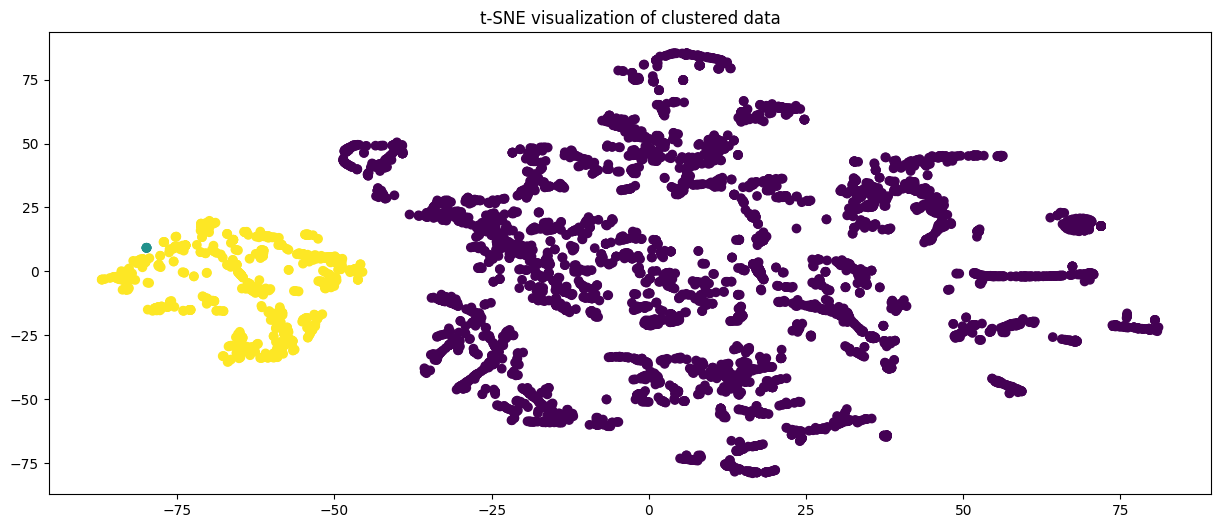

In [28]:
from sklearn.manifold import TSNE
dec.eval()
with torch.no_grad():
    _, z= dec(X_tensor.to(device))
    z_2d = TSNE(n_components=2).fit_transform(z.cpu().numpy())
    plt.figure(figsize=(15,6))
    plt.scatter(z_2d[:,0], z_2d[:,1], c=cluster_ids, cmap='viridis')
    plt.title('t-SNE visualization of clustered data')
    plt.show()

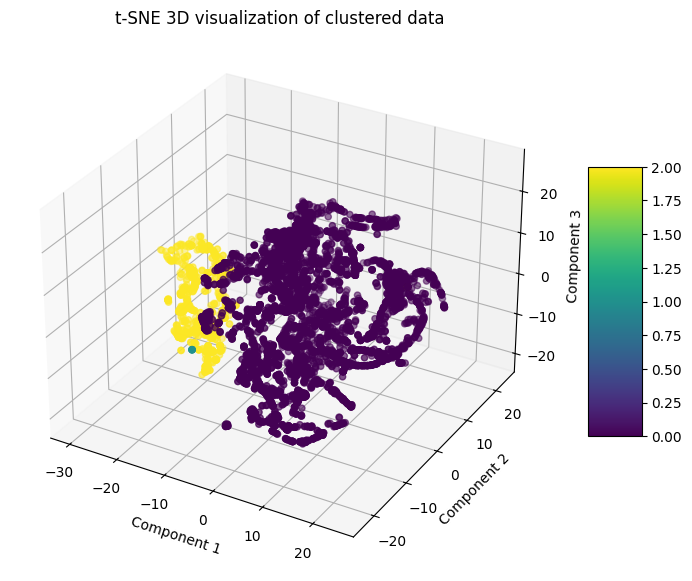

In [29]:
from mpl_toolkits.mplot3d import Axes3D

dec.eval()
with torch.no_grad():
    _, z = dec(X_tensor.to(device))
    z_3d = TSNE(n_components=3, random_state=42).fit_transform(z.cpu().numpy())

    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    scatter = ax.scatter(z_3d[:, 0], z_3d[:, 1], z_3d[:, 2], c=cluster_ids, cmap='viridis', s=20)
    
    ax.set_title('t-SNE 3D visualization of clustered data')
    ax.set_xlabel('Component 1')
    ax.set_ylabel('Component 2')
    ax.set_zlabel('Component 3')
    plt.colorbar(scatter, ax=ax, shrink=0.5, aspect=5)
    plt.show()